**Table of contents**<a id='toc0_'></a>    
- [How many launches per site ?](#toc1_)    
- [How many launches per year ?](#toc2_)    
- [How many active/debris per owner ?](#toc3_)    
- [How many satellites per orbit (LEO, MEO, GEO) ?](#toc4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [2]:
from func.helpers import set_size
np.random.seed(42)

In [3]:
# Set the plots style
custom_params = {"axes.spines.right": False,"axes.spines.top": False,"figure.figsize": set_size(700),"font.size": 10}
sns.set_theme(context='notebook', style='ticks', palette='Blues_r', font='serif', font_scale=1.2, rc=custom_params)

In [4]:
# Load the data
df = pd.read_csv('https://celestrak.org/pub/satcat.csv')
df[['LAUNCH_DATE', 'DECAY_DATE']] = df[['LAUNCH_DATE', 'DECAY_DATE']].apply(pd.to_datetime)
df.head()

,OBJECT_NAME,OBJECT_ID,NORAD_CAT_ID,OBJECT_TYPE,OPS_STATUS_CODE,OWNER,LAUNCH_DATE,LAUNCH_SITE,DECAY_DATE,PERIOD,INCLINATION,APOGEE,PERIGEE,RCS,DATA_STATUS_CODE,ORBIT_CENTER,ORBIT_TYPE
0,SL-1 R/B,1957-001A,1,R/B,D,CIS,1957-10-04,TYMSC,1957-12-01,96.19,65.10,938.0,214.0,20.420,NaN,EA,IMP
1,SPUTNIK 1,1957-001B,2,PAY,D,CIS,1957-10-04,TYMSC,1958-01-03,96.10,65.00,1080.0,64.0,NaN,NaN,EA,IMP
2,SPUTNIK 2,1957-002A,3,PAY,D,CIS,1957-11-03,TYMSC,1958-04-14,103.74,65.33,1659.0,211.0,0.080,NaN,EA,IMP
3,EXPLORER 1,1958-001A,4,PAY,D,US,1958-02-01,AFETR,1970-03-31,88.48,33.15,215.0,183.0,NaN,NaN,EA,IMP
4,VANGUARD 1,1958-002B,5,PAY,NaN,US,1958-03-17,AFETR,NaT,132.60,34.24,3818.0,653.0,0.122,NaN,EA,ORB


In [5]:
df_coords = pd.read_csv('../../data/launch_sites_coords.csv')
df_coords.head()

,code,site_name,latitude,longitude
0,AFETR,"Air Force Eastern Test Range, Florida, USA",28.4889,-80.5778
1,AFWTR,"Air Force Western Test Range, California, USA",34.7420,-120.5724
2,ANDSP,"Andøya Spaceport, Nordland, Norway",69.2940,16.0210
3,ALCLC,"Alcântara Launch Center, Maranhão, Brazil",2.3731,-44.3964
4,BOS,"Bowen Orbital Spaceport, Queensland, Australia",-20.0160,148.2470


# <a id='toc1_'></a>[How many launches per site ?](#toc0_)

In [6]:
launch_site_counts = (
    df.groupby("LAUNCH_SITE", dropna=False)
      .size()
      .sort_values(ascending=False)
      .rename("prop")
)
launch_site_counts /= launch_site_counts.sum()  # Convert to proportions


# Only keeping those that represent more than 1% of the total launches.
launch_site_counts = launch_site_counts[launch_site_counts > 0.01]
df_launches = df_coords.merge(launch_site_counts, left_on='code', right_index=True)
df_launches.head()

,code,site_name,latitude,longitude,prop
0,AFETR,"Air Force Eastern Test Range, Florida, USA",28.4889,-80.5778,0.204368
1,AFWTR,"Air Force Western Test Range, California, USA",34.7420,-120.5724,0.182587
8,FRGUI,"Europe's Spaceport, Kourou, French Guiana",5.2390,-52.7680,0.031283
11,JSC,"Jiuquan Space Center, PRC",40.9606,100.2983,0.017947
17,PLMSC,"Plesetsk Missile and Space Complex, Russia",62.9256,40.5779,0.200079


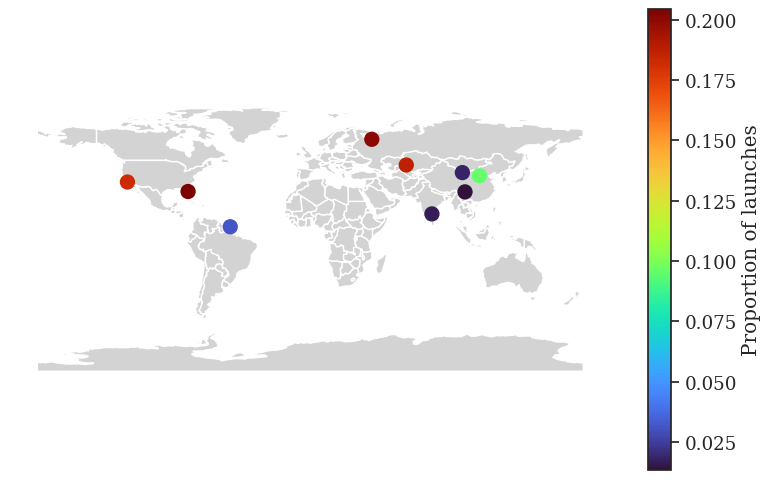

In [7]:
gdf = gpd.GeoDataFrame(df_launches, geometry=gpd.points_from_xy(df_launches['longitude'], df_launches['latitude']))
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
fig, ax = plt.subplots()
world.plot(ax=ax, color='lightgray')
gdf.plot(ax=ax, column='prop', cmap='turbo', markersize=100, legend=True)
if len(fig.axes) > 1:
    fig.axes[1].set_ylabel("Proportion of launches")
ax.set_axis_off()
plt.savefig('./img/launch_sites_map.png', bbox_inches='tight', dpi=300)


# <a id='toc2_'></a>[How many launches per year ?](#toc0_)

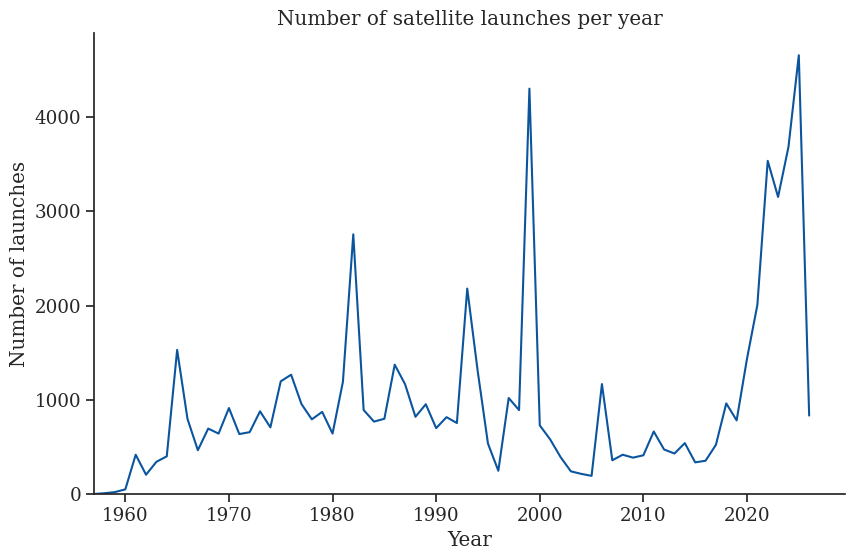

In [8]:
launch_date_counts = (
    df.groupby(df['LAUNCH_DATE'].dt.year, dropna=False)
        .size()
        .sort_values(ascending=False)
        .rename("count")
)

fig, ax = plt.subplots()
sns.lineplot(x=launch_date_counts.index, y=launch_date_counts.values, ax=ax)
ax.set(xlabel='Year', ylabel='Number of launches', title='Number of satellite launches per year')
ax.set_xlim(left=1957)
ax.set_ylim(bottom=0)
plt.savefig('./img/launches_per_year.png', dpi=300, bbox_inches='tight')

# <a id='toc3_'></a>[How many active/debris per owner ?](#toc0_)

In [9]:
df_debris = df[['OWNER','OBJECT_TYPE']].copy().dropna()
df_debris = df_debris[df_debris['OBJECT_TYPE'] != 'UNK']
df_debris['is_debris'] = df_debris['OBJECT_TYPE'].apply(lambda x: 1 if x in ['DEB','R/B'] else 0)
df_debris.head()

,OWNER,OBJECT_TYPE,is_debris
0,CIS,R/B,1
1,CIS,PAY,0
2,CIS,PAY,0
3,US,PAY,0
4,US,PAY,0


In [10]:
debris_per_owner = (
    df_debris.groupby("OWNER", dropna=False)["is_debris"]
    .mean()
    .sort_values(ascending=False)
    .rename("debris_prop")
)

debris_per_owner = debris_per_owner[debris_per_owner > 0.05]
debris_per_owner.head()

OWNER
SEAL    0.972973
ISS     0.955556
CHBZ    0.945652
FR      0.896949
CIS     0.845857
Name: debris_prop, dtype: float64

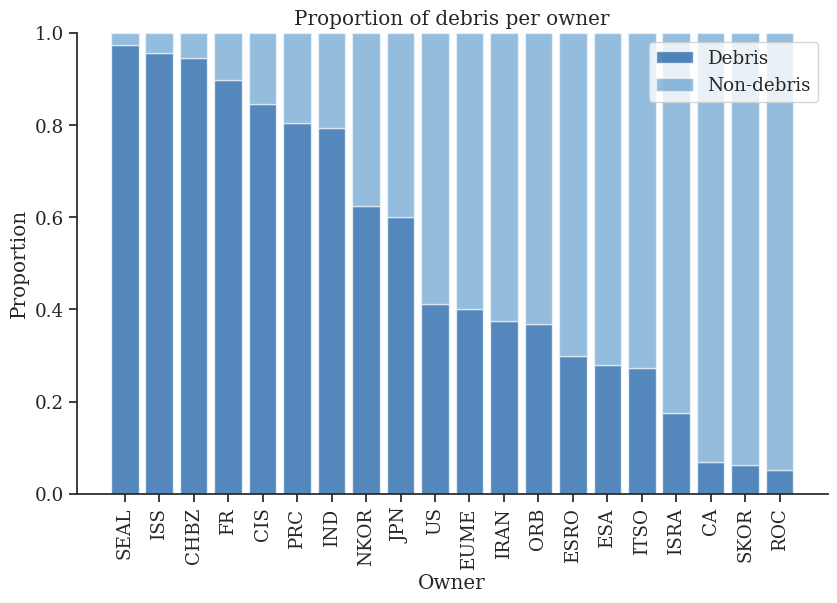

In [11]:
fig, ax = plt.subplots()

x = np.arange(len(debris_per_owner))
debris = debris_per_owner.values
non_debris = 1 - debris

# Partie "débris"
ax.bar(
    x,
    debris,
    label="Debris",
    alpha=0.7
)

#sns.set_color_codes("muted")
# Partie restante jusqu'à 1
ax.bar(
    x,
    non_debris,
    bottom=debris,
    label="Non-debris",
    alpha=0.5
)

ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(debris_per_owner.index, rotation=90)
ax.set_xlabel("Owner")
ax.set_ylabel("Proportion")
ax.set_title("Proportion of debris per owner")
ax.legend()

plt.savefig("./img/debris_per_owner_bar.png", dpi=300, bbox_inches="tight")

# <a id='toc4_'></a>[How many satellites per orbit (LEO, MEO, GEO) ?](#toc0_)

In [12]:
df_earth = (
    df[(df["ORBIT_CENTER"] == "EA") & (~df["OPS_STATUS_CODE"].isin(["?", "D"]))]
    .copy()
    .dropna(subset=["APOGEE", "PERIGEE", "OPS_STATUS_CODE"])
)

conditions = [
    (df_earth["APOGEE"] < 2000),  # LEO
    (df_earth["PERIGEE"] >= 2000) & (df_earth["APOGEE"] < 35000),  # MEO
    (df_earth["PERIGEE"].between(35000, 37000)) & (df_earth["APOGEE"].between(35000, 37000)),  # GEO
]
choices = ["LEO", "MEO", "GEO"]

df_earth["ORBIT_CLASS"] = np.select(conditions, choices, default="OTHER")
df_earth.head()

,OBJECT_NAME,OBJECT_ID,NORAD_CAT_ID,OBJECT_TYPE,OPS_STATUS_CODE,OWNER,LAUNCH_DATE,LAUNCH_SITE,DECAY_DATE,PERIOD,INCLINATION,APOGEE,PERIGEE,RCS,DATA_STATUS_CODE,ORBIT_CENTER,ORBIT_TYPE,ORBIT_CLASS
28,TIROS 1,1960-002B,29,PAY,-,US,1960-04-01,AFETR,NaT,97.39,48.38,650.0,618.0,0.8030,NaN,EA,ORB,LEO
161,TIROS 3,1961-017A,162,PAY,-,US,1961-07-12,AFETR,NaT,99.63,47.90,772.0,709.0,0.8244,NaN,EA,ORB,LEO
225,TIROS 4,1962-002A,226,PAY,-,US,1962-02-08,AFETR,NaT,99.51,48.30,789.0,681.0,0.8120,NaN,EA,ORB,LEO
308,TIROS 5,1962-025A,309,PAY,-,US,1962-06-19,AFETR,NaT,98.59,58.09,824.0,559.0,0.7711,NaN,EA,ORB,LEO
396,TIROS 6,1962-047A,397,PAY,-,US,1962-09-18,AFETR,NaT,96.27,58.30,589.0,571.0,0.7579,NaN,EA,ORB,LEO


In [13]:
orbit_counts = (
    df_earth["ORBIT_CLASS"]
    .value_counts(dropna=False, normalize=True)
    .mul(100)
    .reindex(choices+["OTHER"], fill_value=0)
)
orbit_counts.head()

ORBIT_CLASS
LEO      89.283546
MEO       2.374013
GEO       7.492410
OTHER     0.850030
Name: proportion, dtype: float64

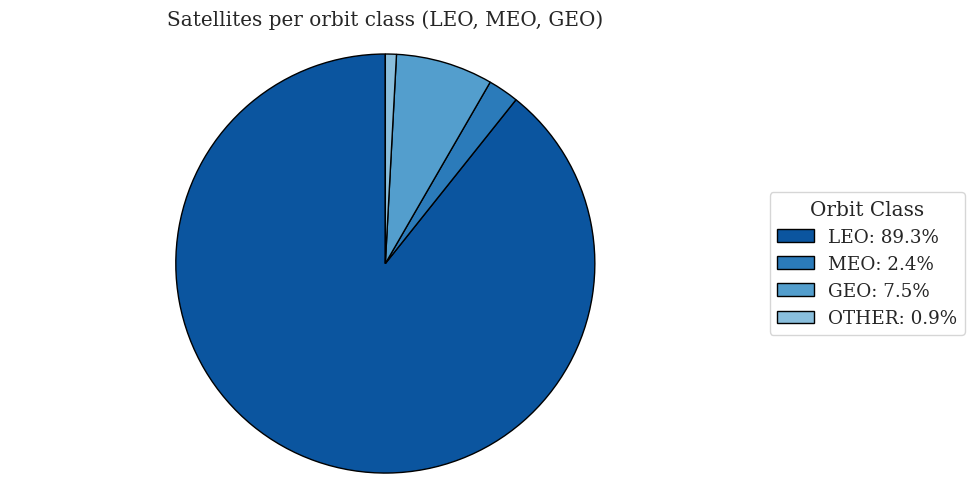

In [14]:
fig, ax = plt.subplots()
ax.pie(
    x=orbit_counts.values,
    startangle=90,
    wedgeprops={"edgecolor": "black"}
)
ax.legend(
    [f"{label}: {count:.1f}%" for label, count in zip(orbit_counts.index, orbit_counts.values)],
    title="Orbit Class",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
ax.set_title("Satellites per orbit class (LEO, MEO, GEO)")
ax.axis("equal")
plt.savefig("./img/satellites_per_orbit_pie.png", dpi=300, bbox_inches="tight")